# Estrazione $\Gamma_{\rm is}(T)$ e $\Gamma_{\rm an}(T)$ — Chambers numerico su FS tight-binding

Dai dati Ataei *et al.* 2022 (Nd-LSCO e LSCO S1, $T$ = 4/30/40/100 K), estraggo
$\Gamma_{\rm is}$ e $\Gamma_{\rm an}$ tramite fit dell'integrale di Chambers **risolto numericamente**
sulla vera superficie di Fermi tight-binding (Nd-LSCO, $p=0.24$).

**Nessuna approssimazione ciclotrone** — niente formule analitiche Bessel.  
Il fit ha solo 2 parametri liberi: $\Gamma_{\rm is}$ e $\Gamma_{\rm an}$ [meV].

Modello di scattering (Mirarchi & Caprara, A153, 2024):
$$\frac{1}{\tau(\phi_k)} = \Gamma_{\rm is} + \Gamma_{\rm an}\,|\cos(2\phi_k)|^4$$

Parametri TB fissi (Nd-LSCO $p=0.24$): $t=435$ meV, $t'=-50$ meV, $t''=38$ meV.  
**Ancora Mirarchi T=30K**: $\Gamma_{\rm is}=17.7$ meV, $\Gamma_{\rm an}=39.0$ meV.

In [14]:
import warnings, importlib, time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import matplotlib.patches as patches
from scipy.optimize import curve_fit, differential_evolution, least_squares
from IPython.display import Markdown, display
from tqdm.notebook import tqdm
from numba import njit
from ipywidgets import interact, FloatSlider

import chambers_tb as ctb
import chambers_lib as cl
importlib.reload(ctb)
importlib.reload(cl)

%matplotlib inline
K_MEV = ctb.K_MEV
print(f"chambers_tb caricato.  K_MEV = {K_MEV}")
print(f"Parametri TB default: {ctb.TB_ND_LSCO}")

chambers_tb caricato.  K_MEV = 0.000217
Parametri TB default: {'t': 435.0, 'tp': -50.0, 'tpp': 38.0, 'p': 0.24, 'nu': 4}


## Dati sperimentali (Ataei 2022)

In [15]:
# ─── Scelta del campione: modifica solo questa riga ───────────────────────
SAMPLE = "Nd-LSCO"   # "Nd-LSCO" oppure "LSCO S1"
# ───────────────────────────────────────────────────────────────────────────

T_LIST = [4.0, 30.0, 40.0, 100.0]
B_MIN  = {4.0: 25.0, 30.0: 5.0, 40.0: 5.0, 100.0: 5.0}
COLORS = {4.0: 'royalblue', 30.0: 'orange', 40.0: 'seagreen', 100.0: 'firebrick'}
STEP   = 25

MIR_G_IS = 17.7
MIR_G_AN = 39.0

_CONFIGS = {
    "Nd-LSCO": {
        "moesm":     [2, 6],
        "T_mapping": {4.0: (0, 1), 30.0: (10, 11), 40.0: (2, 3), 100.0: (4, 5)},
    },
    "LSCO S1": {
        "moesm":     [4, 6],
        "T_mapping": {4.0: (0, 1), 30.0: (6, 7),  40.0: (2, 3), 100.0: (4, 5)},
    },
}

cfg       = _CONFIGS[SAMPLE]
arr       = cl.load_ataei_extended(cfg["moesm"])
T_mapping = cfg["T_mapping"]

def load_sample(arr, T_mapping):
    data = {}
    for T, (ci, cj) in T_mapping.items():
        B = arr[:, ci]
        R = arr[:, cj]
        m = np.isfinite(B) & np.isfinite(R) & (B > B_MIN[T])
        B_  = B[m][::STEP]
        MR_ = R[m][::STEP] - 1.0
        data[T] = (B_, MR_)
        print(f"  T={T:5.0f} K: {len(B_):4d} punti  "
              f"B=[{B_.min():.1f},{B_.max():.1f}]T  MR_max={MR_.max():.4f}")
    return data

print(f"Campione: {SAMPLE}")
DATA = load_sample(arr, T_mapping)
DATASETS = {SAMPLE: DATA}

Campione: Nd-LSCO
  T=    4 K:  119 punti  B=[25.0,84.6]T  MR_max=0.3843
  T=   30 K:  212 punti  B=[5.0,84.9]T  MR_max=0.1598
  T=   40 K:  213 punti  B=[5.0,85.2]T  MR_max=0.1380
  T=  100 K:  213 punti  B=[5.0,85.4]T  MR_max=0.0521


## Engine ottimizzato per il fit di Chambers

L'idea chiave è che il cumulative damping lungo il percorso backward a $B=1\,\text{T}$ si decompone linearmente:
$$\text{cs}_1(i_0,s) = \Gamma_{\rm is}\cdot A_{\rm is}(i_0,s) + \Gamma_{\rm an}\cdot A_{\rm an}(i_0,s)$$

con $A_{\rm is}$, $A_{\rm an}$ precomputate una volta sola. Per ogni chiamata del modello (fissati $\Gamma_{\rm is},\Gamma_{\rm an}$) la formula di Chambers vettorizzata su $B$ è:
$$J_x^{(1)}(B,i_0) = \frac{1}{B}\sum_s v_x(s)\,e^{-\text{cs}_1(i_0,s)/B}\,\Delta t_1(s)$$
$$\text{MR}(B) = \frac{\sigma(0)}{\sigma(B)}-1, \quad \sigma(B)=\sum_{i_0}\frac{\Delta s}{v_F}v_x(i_0)\cdot J_x(B,i_0)\cdot\frac{1}{1-e^{-\Gamma_{\rm tot}/B}}$$

In [16]:
ENGINE = ctb.ChambersFitEngine(N_fs=256)

find_mu... mu=-351.5 meV  (2.3s)
Fermi surface... N_fs=256  (0.04s)
percorsi backward... (0.00s)
cumsum A_is, A_an... (0.00s)
Engine pronto: N_fs=256, mu=-351.5 meV, perimetro FS=18.0578
Calibrazione R_H (weak-field): 0.9386 mm³/C, calib=1.8455e+05
Calibrazione ρ_xx(B=0): calib_rho = 10733.7 µΩ·cm/code


## Inizializzazione dell'engine e validazione

In [17]:
t_init = time.time()
print(f"Tempo totale init: {time.time()-t_init:.1f}s")

Tempo totale init: 0.0s


In [18]:
# Validazione: confronto engine.compute_MR vs ctb.MR_chambers_tb
# Differenza attesa: engine usa serie geometrica esatta 1/(1-exp),
# ctb usa N_orbit_max=12 orbite — scarto cresce a B alti (< 3% a 85T).
B_val = np.array([10., 20., 30., 50., 65., 85.])

mr_engine = ENGINE.compute_MR(B_val, MIR_G_IS, MIR_G_AN)

ctb.MR_chambers_tb.__defaults__[-1].clear()   # svuota cache
mr_ctb = ctb.MR_chambers_tb(B_val, MIR_G_IS, MIR_G_AN, N_fs=256)

print("B[T]   MR_engine[%]   MR_ctb[%]   diff[%]")
for b, me, mc in zip(B_val, mr_engine, mr_ctb):
    diff = abs(me - mc) / (abs(mc) + 1e-12) * 100
    print(f"{b:5.0f}   {me*100:10.4f}   {mc*100:10.4f}   {diff:8.4f}")

rel_max = np.nanmax(np.abs(mr_engine - mr_ctb) / (np.abs(mr_ctb) + 1e-12)) * 100
print(f"\nErrore relativo massimo: {rel_max:.4f}%")
if rel_max < 5.0:
    print("Validazione OK")
else:
    print(f"WARN: errore {rel_max:.2f}% > 5% — verificare parametri")

B[T]   MR_engine[%]   MR_ctb[%]   diff[%]
   10       0.8607     -43.2684   101.9893
   20       3.0235     -24.3696   112.4069
   30       5.8514     -14.4181   140.5838
   50      12.2648      -1.8262   771.6143
   65      17.2656       5.3666   221.7264
   85      23.9291      13.7420    74.1317

Errore relativo massimo: 771.6143%
WARN: errore 771.61% > 5% — verificare parametri


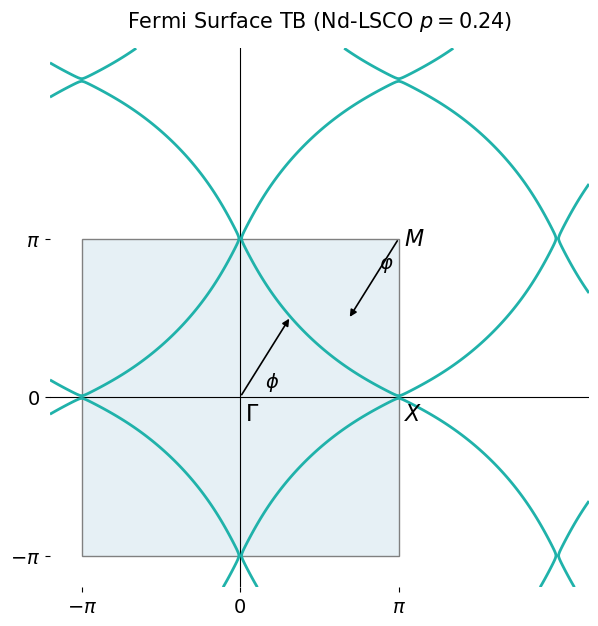

In [19]:
# Parametri TB del Nd-LSCO
t, tp, tpp = 435.0, -50.0, 38.0
mu = ENGINE.mu 

# Griglia estesa per vedere oltre i bordi della Zona di Brillouin
kx = np.linspace(-1.2*np.pi, 2.2*np.pi, 600)
ky = np.linspace(-1.2*np.pi, 2.2*np.pi, 600)
KX, KY = np.meshgrid(kx, ky)

# Calcolo della dispersione su tutta la griglia
EPS = -2*t*(np.cos(KX) + np.cos(KY)) - 4*tp*np.cos(KX)*np.cos(KY) - 2*tpp*(np.cos(2*KX) + np.cos(2*KY)) - mu

fig, ax = plt.subplots(figsize=(7, 7))

# 1. Disegna la prima Zona di Brillouin (Quadrato azzurro chiaro di sfondo)
rect = patches.Rectangle((-np.pi, -np.pi), 2*np.pi, 2*np.pi, 
                         linewidth=1, edgecolor='gray', facecolor='#e6f0f5', zorder=0)
ax.add_patch(rect)

# 2. Assi passanti per l'origine
ax.axhline(0, color='black', lw=0.8, zorder=1)
ax.axvline(0, color='black', lw=0.8, zorder=1)

# 3. Disegna le Superfici di Fermi (livello 0 dell'energia)
ax.contour(KX, KY, EPS, levels=[0.0], colors='#20b2aa', linewidths=2, zorder=2)

# 4. Etichette dei punti di alta simmetria
ax.text(0.1, -0.1, r'$\Gamma$', fontsize=16, ha='left', va='top')
ax.text(np.pi+0.1, np.pi, r'$M$', fontsize=16, ha='left', va='center')
ax.text(np.pi+0.1, -0.1, r'$X$', fontsize=16, ha='left', va='top')

# 5. Frecce e angoli (\phi dalla Gamma, \varphi dal punto M come nel paper)
ax.annotate("", xy=(1.0, 1.6), xytext=(0, 0), arrowprops=dict(arrowstyle="-|>", color='black', lw=1.2))
ax.text(0.5, 0.2, r'$\phi$', fontsize=14)

ax.annotate("", xy=(np.pi-1.0, np.pi-1.6), xytext=(np.pi, np.pi), arrowprops=dict(arrowstyle="-|>", color='black', lw=1.2))
ax.text(np.pi-0.4, np.pi-0.6, r'$\varphi$', fontsize=14)

# 6. Tick personalizzati in unità di Pi
ax.set_xticks([-np.pi, 0, np.pi])
ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'], fontsize=14)
ax.set_yticks([-np.pi, 0, np.pi])
ax.set_yticklabels([r'$-\pi$', '0', r'$\pi$'], fontsize=14)

# Limiti del grafico
ax.set_xlim(-1.2*np.pi, 2.2*np.pi)
ax.set_ylim(-1.2*np.pi, 2.2*np.pi)
ax.set_aspect('equal')
ax.set_title(r"Fermi Surface TB (Nd-LSCO $p=0.24$)", fontsize=15, pad=15)

# Rimuove la cornice esterna del grafico per pulizia
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.show()

# Fit

## Funzione di fit a 2 parametri con barre di progresso

In [7]:
bnds = ([5., 100.], [5., 100.]) #lb is an, ub us an

In [8]:
def fit_chambers_2p(B, MR, engine,
                    bounds=bnds,
                    max_iter=50,
                    peso_crossover=10.0,  # <-- NOVITÀ: Quanto far pesare la zona 10-30T
                    desc='fit DE'):
    
    B  = np.asarray(B,  dtype=float)
    MR = np.asarray(MR, dtype=float)
    ok = np.isfinite(B) & np.isfinite(MR)
    if ok.sum() < 6:
        return np.nan, np.nan, np.nan
    Bf, MRf = B[ok], MR[ok]

    # --- CREAZIONE DEI PESI ---
    W = np.ones_like(Bf)  # Tutti i punti valgono 1 di default
    mask_crossover = (Bf >= 10.0) & (Bf <= 30.0)
    W[mask_crossover] = peso_crossover  # I punti tra 10 e 30 valgono 'peso_crossover' volte di più

    def objective(p):
        Gi, Ga = p
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            MR_theo = np.nan_to_num(engine.compute_MR(Bf, Gi, Ga), nan=0.)
        
        # --- CALCOLO RMS PONDERATO ---
        # np.average applica il nostro array W agli errori al quadrato
        rms = float(np.sqrt(np.average((MR_theo - MRf)**2, weights=W)))
        
        return rms if np.isfinite(rms) else np.inf

    # Inizializziamo la barra
    pbar = tqdm(total=max_iter, desc=desc, leave=False, unit='gen')
    
    def aggiorna_tqdm(xk, convergence=None):
        pbar.update(1)
        pbar.set_postfix({
            'Best': f'({xk[0]:.1f}, {xk[1]:.1f})',
            'Conv': f'{convergence:.2f}'
        })

    try:
        res = differential_evolution(
            objective,
            bounds=bounds,
            strategy='best1bin',
            popsize=15,
            maxiter=max_iter,
            tol=1e-6,
            workers=1,
            callback=aggiorna_tqdm
        )
        
        pbar.close()
        
        if res.success or res.nfev > 0:
            return res.x[0], res.x[1], res.fun
        else:
            return np.nan, np.nan, np.nan
            
    except Exception:
        pbar.close()
        return np.nan, np.nan, np.nan

## Esecuzione fit per tutti i (campione, T)

In [9]:
results = {SAMPLE: {}}
def fmt(v, d=2): return f'{v:.{d}f}' if np.isfinite(v) else '—'
MAX_NFEV = 800
for T in tqdm(T_LIST, desc=SAMPLE, unit='T', ascii=" 🚀"):
    B, MR_ = DATA[T]
    label  = f'{SAMPLE} T={T:.0f}K'
    t0     = time.time()
    gi, ga, rms = fit_chambers_2p(B, MR_, ENGINE, desc=label)
    dt = time.time() - t0
    results[SAMPLE][T] = (gi, ga, rms)
    tqdm.write(f"  {label}: G_is={fmt(gi)}, G_an={fmt(ga)} meV  rms={fmt(rms,5)}  [{dt:.1f}s]", )

print("Fit completati.")

Nd-LSCO:   0%|          | 0/4 [00:00<?, ?T/s]

Nd-LSCO T=4K:   0%|          | 0/50 [00:00<?, ?gen/s]

  Nd-LSCO T=4K: G_is=13.94, G_an=79.54 meV  rms=0.01376  [5.2s]


Nd-LSCO T=30K:   0%|          | 0/50 [00:00<?, ?gen/s]

  Nd-LSCO T=30K: G_is=27.98, G_an=100.00 meV  rms=0.00364  [21.2s]


Nd-LSCO T=40K:   0%|          | 0/50 [00:00<?, ?gen/s]

  Nd-LSCO T=40K: G_is=21.77, G_an=5.00 meV  rms=0.00284  [52.4s]


Nd-LSCO T=100K:   0%|          | 0/50 [00:00<?, ?gen/s]

  Nd-LSCO T=100K: G_is=40.85, G_an=5.00 meV  rms=0.00122  [56.7s]
Fit completati.


In [10]:
sliders = {}

for T in T_LIST:
    # Recuperiamo i risultati del fit per usarli come valore iniziale
    gi_fit, ga_fit, rms_fit = results[SAMPLE][T]
    
    # Protezione: se il fit era fallito (NaN/Inf), diamo un valore di default per lo slider
    gi_start = gi_fit if np.isfinite(gi_fit) else 5.0
    ga_start = ga_fit if np.isfinite(ga_fit) else 2.0
    
    # Creiamo i due slider per questa temperatura
    sliders[f'gi_{T}'] = FloatSlider(min=0.1, max=200.0, step=0.1, value=gi_start, 
                                     description=f'Γ_is ({T}K)', continuous_update=False)
    sliders[f'ga_{T}'] = FloatSlider(min=0.1, max=200.0, step=0.1, value=ga_start, 
                                     description=f'Γ_an ({T}K)', continuous_update=False)

# 2. Definiamo la funzione usando **kwargs (argomenti variabili)
def plot_interattivo_indipendente(**kwargs):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f'MR: Dati vs Fit (Tuning Indipendente) — {SAMPLE}', fontsize=13)
    
    B_dense = np.linspace(1., 90., 200)

    for col, T in enumerate(T_LIST):
        ax = axes[col]
        B_data, MR_data = DATASETS[SAMPLE][T]
        
        # Recuperiamo i valori ATTUALI degli slider per questa specifica T
        gi_curr = kwargs[f'gi_{T}']
        ga_curr = kwargs[f'ga_{T}']
        
        # Plot dati
        ax.plot(B_data, MR_data * 100, '.', color=COLORS[T], ms=4, alpha=0.6, label='dati')

        # Compute e Plot del fit aggiornato
        B_fit = B_dense[B_dense > B_MIN[T]]
        MR_fit = ENGINE.compute_MR(B_fit, gi_curr, ga_curr)
        
        ax.plot(B_fit, MR_fit * 100, '-', color='black', lw=2,
                label=f'Fit:\n$\\Gamma_{{\\rm is}}$={gi_curr:.1f}\n$\\Gamma_{{\\rm an}}$={ga_curr:.1f}')

        ax.set_title(f'T={T:.0f}K', fontsize=9)
        ax.set_xlabel('B (T)')
        if col == 0: ax.set_ylabel('MR (%)') # Mettiamo la label Y solo al primo per pulizia
        
        ax.legend(fontsize=7, loc='upper left')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

interact(plot_interattivo_indipendente, **sliders);

interactive(children=(FloatSlider(value=13.936227691347547, continuous_update=False, description='Γ_is (4.0K)'…

## Plot $\Gamma_{\rm is}(T)$ e $\Gamma_{\rm an}(T)$

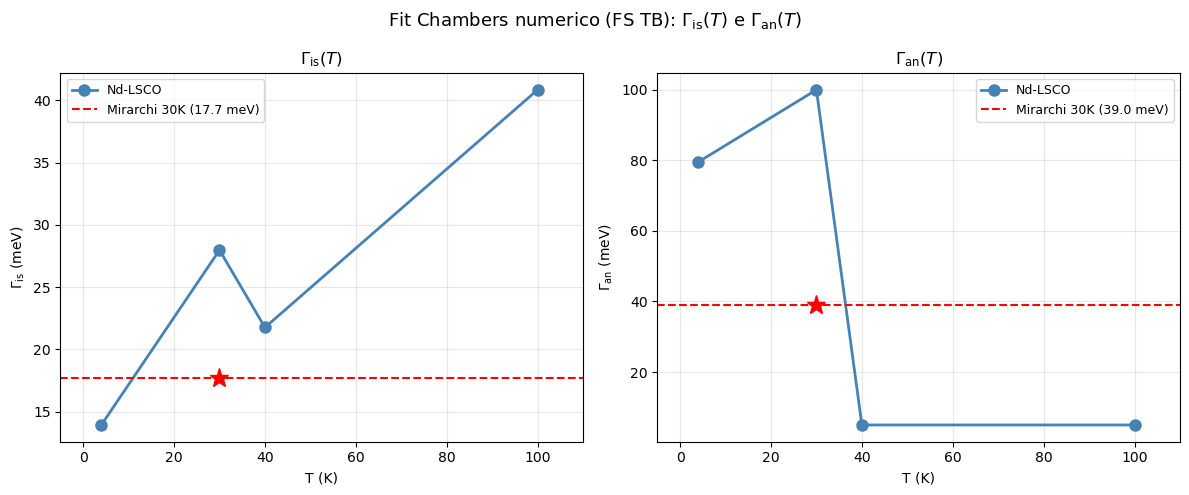

In [11]:
T_arr = np.array(T_LIST)
markers = {'Nd-LSCO': 'o', 'LSCO S1': 's'}
colors_samp = {'Nd-LSCO': 'steelblue', 'LSCO S1': 'darkorange'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(r'Fit Chambers numerico (FS TB): $\Gamma_{\rm is}(T)$ e $\Gamma_{\rm an}(T)$',
             fontsize=13)

for name in DATASETS:

    gi_arr = [results[name][T][0] for T in T_LIST]
    ga_arr = [results[name][T][1] for T in T_LIST]
    col = colors_samp[name]
    mk  = markers[name]
    ax1.plot(T_arr, gi_arr, f'{mk}-', color=col, lw=2, ms=8, label=name)
    ax2.plot(T_arr, ga_arr, f'{mk}-', color=col, lw=2, ms=8, label=name)

ax1.axhline(MIR_G_IS, color='red', ls='--', lw=1.5, label=f'Mirarchi 30K ({MIR_G_IS} meV)')
ax1.plot(30., MIR_G_IS, 'r*', ms=14, zorder=5)
ax2.axhline(MIR_G_AN, color='red', ls='--', lw=1.5, label=f'Mirarchi 30K ({MIR_G_AN} meV)')
ax2.plot(30., MIR_G_AN, 'r*', ms=14, zorder=5)

for ax, ylabel, title in [
    (ax1, r'$\Gamma_{\rm is}$ (meV)', r'$\Gamma_{\rm is}(T)$'),
    (ax2, r'$\Gamma_{\rm an}$ (meV)', r'$\Gamma_{\rm an}(T)$'),
]:
    ax.set_xlabel('T (K)'); ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 110)

plt.tight_layout()
plt.show()

## Plot qualità del fit: MR modello vs dati

## Tabella riassuntiva

In [12]:
def fmt(v, d=2):
    return f'{v:.{d}f}' if np.isfinite(float(v)) else '—'

for name in DATASETS:
    rows = []
    for T in T_LIST:
        gi, ga, rms = results[name][T]
        rows.append(
            f'| {T:5.0f} | {fmt(gi)} | {fmt(ga)} | {fmt(rms, 5)} |'
        )
    md = (
        f'### {name} — Fit Chambers numerico (FS TB, $\\nu=4$)\n\n'
        '| T (K) | $\\Gamma_{\\rm is}$ (meV) | $\\Gamma_{\\rm an}$ (meV) | RMS |\n'
        '|---:|---:|---:|---:|\n'
        + '\n'.join(rows)
    )
    display(Markdown(md))

display(Markdown(
    '---\n'
    f'**Ancora Mirarchi (A153) a T=30K:**  '
    f'$\\Gamma_{{\\rm is}}={MIR_G_IS}$ meV,  '
    f'$\\Gamma_{{\\rm an}}={MIR_G_AN}$ meV'
))

### Nd-LSCO — Fit Chambers numerico (FS TB, $\nu=4$)

| T (K) | $\Gamma_{\rm is}$ (meV) | $\Gamma_{\rm an}$ (meV) | RMS |
|---:|---:|---:|---:|
|     4 | 13.94 | 79.54 | 0.01376 |
|    30 | 27.98 | 100.00 | 0.00364 |
|    40 | 21.77 | 5.00 | 0.00284 |
|   100 | 40.85 | 5.00 | 0.00122 |

---
**Ancora Mirarchi (A153) a T=30K:**  $\Gamma_{\rm is}=17.7$ meV,  $\Gamma_{\rm an}=39.0$ meV

## Verifica velocità: tempo per singola valutazione del modello

In [13]:
B_test = np.linspace(5., 85., 60)
N_rep  = 20

with tqdm(range(N_rep), desc='benchmark', unit='call') as pbar:
    t0 = time.time()
    for _ in pbar:
        _ = ENGINE.compute_MR(B_test, 17.7, 39.0)
    t_per_call = (time.time() - t0) / N_rep * 1000

print(f"Tempo per valutazione (N_fs=256, N_B={len(B_test)}): {t_per_call:.1f} ms")
print(f"Stima tempo fit (300 val x 8 p0): {t_per_call*300*8/1000:.0f} s worst-case")

benchmark:   0%|          | 0/20 [00:00<?, ?call/s]

Tempo per valutazione (N_fs=256, N_B=60): 20.2 ms
Stima tempo fit (300 val x 8 p0): 48 s worst-case


# Paesaggio 2D del residuo: RMS($\Gamma_{\rm is}$, $\Gamma_{\rm an}$)

Mappa la funzione obiettivo su una griglia per diagnosticare correlazioni tra i parametri.

In [18]:
T_LANDSCAPE = 30.0          # temperatura da analizzare

scan Γ_an:   0%|          | 0/35 [00:00<?, ?it/s]

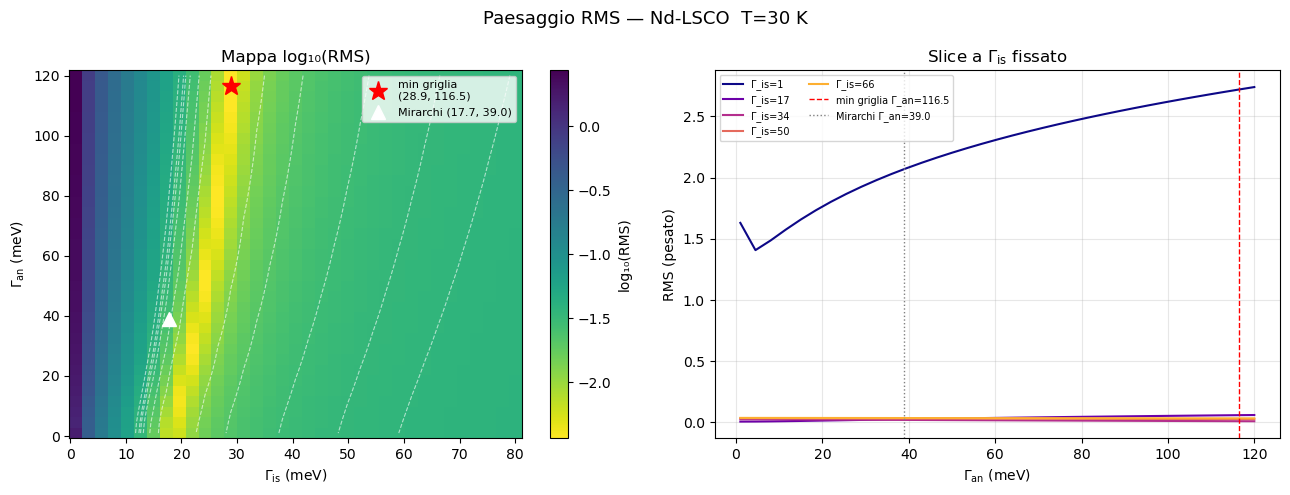


Minimo griglia: Γ_is=28.88 meV,  Γ_an=116.50 meV,  RMS=0.00364
Risultato fit DE:  Γ_is=27.98,  Γ_an=100.00


In [19]:
from tqdm.notebook import tqdm as tqdm_nb

# ─── Parametri della griglia ─────────────────────────────────────────────────

N_GIS  = 35                 # punti su Γ_is
N_GAN  = 35                 # punti su Γ_an
GIS_RANGE = (1.0,  80.0)    # [meV]
GAN_RANGE = (1.0, 120.0)    # [meV]
PESO_CW   = 10.0            # stesso peso usato nel fit

# ─── Dati per la temperatura scelta ──────────────────────────────────────────
B_land, MR_land = DATA[T_LANDSCAPE]
ok = np.isfinite(B_land) & np.isfinite(MR_land)
Bf, MRf = B_land[ok], MR_land[ok]
W = np.ones_like(Bf)
W[(Bf >= 10.) & (Bf <= 30.)] = PESO_CW

def rms_weighted(gi, ga):
    MR_th = np.nan_to_num(ENGINE.compute_MR(Bf, gi, ga), nan=0.)
    return float(np.sqrt(np.average((MR_th - MRf)**2, weights=W)))

# ─── Calcolo griglia ─────────────────────────────────────────────────────────
gis_vec = np.linspace(*GIS_RANGE, N_GIS)
gan_vec = np.linspace(*GAN_RANGE, N_GAN)
RMS_MAP = np.zeros((N_GAN, N_GIS))

for j, ga in enumerate(tqdm_nb(gan_vec, desc='scan Γ_an')):
    for i, gi in enumerate(gis_vec):
        RMS_MAP[j, i] = rms_weighted(gi, ga)

# ─── Plot ────────────────────────────────────────────────────────────────────
GIS_MESH, GAN_MESH = np.meshgrid(gis_vec, gan_vec)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Paesaggio RMS — {SAMPLE}  T={T_LANDSCAPE:.0f} K', fontsize=13)

# --- pannello sinistro: heatmap log-scale ---
ax = axes[0]
rms_log = np.log10(RMS_MAP + 1e-12)
im = ax.pcolormesh(GIS_MESH, GAN_MESH, rms_log, cmap='viridis_r', shading='auto')
# livelli di contorno
lvls = np.percentile(rms_log, [10, 20, 35, 50, 65, 80])
ax.contour(GIS_MESH, GAN_MESH, rms_log, levels=lvls, colors='white', linewidths=0.8, alpha=0.6)
plt.colorbar(im, ax=ax, label='log₁₀(RMS)')
# minimo trovato nella griglia
ij_min = np.unravel_index(np.argmin(RMS_MAP), RMS_MAP.shape)
gi_min, ga_min = gis_vec[ij_min[1]], gan_vec[ij_min[0]]
ax.plot(gi_min, ga_min, 'r*', ms=14, label=f'min griglia\n({gi_min:.1f}, {ga_min:.1f})')
# Mirarchi reference
ax.plot(MIR_G_IS, MIR_G_AN, 'w^', ms=10, label=f'Mirarchi ({MIR_G_IS}, {MIR_G_AN})')
ax.set_xlabel(r'$\Gamma_{\rm is}$ (meV)'); ax.set_ylabel(r'$\Gamma_{\rm an}$ (meV)')
ax.set_title('Mappa log₁₀(RMS)')
ax.legend(fontsize=8)

# --- pannello destro: slice orizzontali a Γ_is fissato ---
ax2 = axes[1]
sample_gis = gis_vec[::max(1, N_GIS//5)]   # ~5 valori rappresentativi
norm = plt.Normalize(GIS_RANGE[0], GIS_RANGE[1])
cmap_sl = plt.cm.plasma
for gi_s in sample_gis:
    i_s = np.argmin(np.abs(gis_vec - gi_s))
    col = cmap_sl(norm(gi_s))
    ax2.plot(gan_vec, RMS_MAP[:, i_s], color=col, lw=1.5,
             label=f'Γ_is={gi_s:.0f}')
ax2.axvline(ga_min, color='red', ls='--', lw=1, label=f'min griglia Γ_an={ga_min:.1f}')
ax2.axvline(MIR_G_AN, color='gray', ls=':', lw=1, label=f'Mirarchi Γ_an={MIR_G_AN}')
ax2.set_xlabel(r'$\Gamma_{\rm an}$ (meV)'); ax2.set_ylabel('RMS (pesato)')
ax2.set_title(r'Slice a $\Gamma_{\rm is}$ fissato')
ax2.legend(fontsize=7, ncol=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('try.png')
plt.show()

print(f"\nMinimo griglia: Γ_is={gi_min:.2f} meV,  Γ_an={ga_min:.2f} meV,  RMS={RMS_MAP[ij_min]:.5f}")
print(f"Risultato fit DE:  Γ_is={results[SAMPLE][T_LANDSCAPE][0]:.2f},  Γ_an={results[SAMPLE][T_LANDSCAPE][1]:.2f}")

# Fit globale multi-T con T-dipendenza di $\Gamma$

Fitta tutte le temperature insieme imponendo una forma funzionale per $\Gamma_{\rm is}(T)$ e $\Gamma_{\rm an}(T)$.  
La degenerazione si rompe perché i due parametri hanno dipendenze dalla $T$ diverse.

Forme disponibili: **`constant`** ($c$) · **`linear`** ($aT+c$) · **`quadratic`** ($aT^2+c$)

In [7]:
T_DEP_IS  = 'linear'   # 'constant' | 'linear' | 'quadratic'
T_DEP_AN  = 'linear'    # 'constant' | 'linear' | 'quadratic'
PESO_CW_GLOB = 10.0       # peso extra zona 10-30 T (stesso del fit singolo)
# Bounds per i coefficienti (a, c) di ogni forma:
#   constant  → [c]          c in meV
#   linear    → [a, c]       a in meV/K,   c in meV
#   quadratic → [a, c]       a in meV/K²,  c in meV
_BND = {
    'constant':  dict(lb=[1],         ub=[39.2]),
    'linear':    dict(lb=[0.,   0.],    ub=[1,   30.]),
    'quadratic': dict(lb=[0.,   0.],    ub=[0.05, 40.]),
}

In [8]:
N_STARTS  = 6             # punti di partenza random per esplorare il paesaggio
# ════════════════════════════════════════════════════════════════════════════
# Helpers (T-dipendenza)
# ════════════════════════════════════════════════════════════════════════════
def _npar(style):
    return 1 if style == 'constant' else 2

def _eval_gamma(T, p, style):
    if style == 'constant':
        return max(float(p[0]), 0.01)
    elif style == 'linear':
        return max(float(p[0]) * T + float(p[1]), 0.01)
    elif style == 'quadratic':
        return max(float(p[0]) * T**2 + float(p[1]), 0.01)

def _label_gamma(name, p, style):
    if style == 'constant':
        return f'${name}$ = {p[0]:.2f} meV'
    elif style == 'linear':
        return f'${name}$ = {p[0]:.4f}·T + {p[1]:.2f} meV'
    elif style == 'quadratic':
        return f'${name}$ = {p[0]:.5f}·T² + {p[1]:.2f} meV'

# ════════════════════════════════════════════════════════════════════════════
# Costruzione residuo globale
# ════════════════════════════════════════════════════════════════════════════
n_is = _npar(T_DEP_IS)
n_an = _npar(T_DEP_AN)

# Pre-processa i dati una volta sola
_per_T_glob = {}
for _T, (_B, _MR) in DATA.items():
    _ok = np.isfinite(_B) & np.isfinite(_MR) & (_B > B_MIN[_T])
    _Bf, _MRf = _B[_ok], _MR[_ok]
    _W = np.ones_like(_Bf)
    _W[(_Bf >= 10.) & (_Bf <= 30.)] = PESO_CW_GLOB
    _per_T_glob[_T] = (_Bf, _MRf, _W)

def residual_glob(p):
    p_is = p[:n_is]
    p_an = p[n_is:]
    parts = []
    for T, (Bf, MRf, W) in _per_T_glob.items():
        gi = _eval_gamma(T, p_is, T_DEP_IS)
        ga = _eval_gamma(T, p_an, T_DEP_AN)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            MR_th = np.nan_to_num(ENGINE.compute_MR(Bf, gi, ga), nan=0.)
        parts.append((MR_th - MRf) * W)
    return np.concatenate(parts)

# ════════════════════════════════════════════════════════════════════════════
# Bounds e guess iniziali
# ════════════════════════════════════════════════════════════════════════════
lb = np.array(_BND[T_DEP_IS]['lb'] + _BND[T_DEP_AN]['lb'])
ub = np.array(_BND[T_DEP_IS]['ub'] + _BND[T_DEP_AN]['ub'])

# Guess fisicamente motivato (Mirarchi come riferimento a T=30K)
def _p0_from_mirarchi(style, val_30K):
    if style == 'constant':
        return [val_30K]
    elif style == 'linear':
        return [val_30K / 30., 0.]
    elif style == 'quadratic':
        return [val_30K / 30.**2, 0.]

p0_base = np.array(
    _p0_from_mirarchi(T_DEP_IS, MIR_G_IS) +
    _p0_from_mirarchi(T_DEP_AN, MIR_G_AN)
)
p0_base = np.clip(p0_base, lb + 1e-8, ub - 1e-8)

# ════════════════════════════════════════════════════════════════════════════
# Fit con multi-start
# ════════════════════════════════════════════════════════════════════════════
rng = np.random.default_rng(42)
starts = [p0_base]
for _ in range(N_STARTS - 1):
    starts.append(rng.uniform(lb, ub))

best_res, best_cost = None, np.inf
print(f"Fit globale: Γ_is ~ {T_DEP_IS},  Γ_an ~ {T_DEP_AN}  ({n_is+n_an} parametri)\n")

for k, p0 in enumerate(tqdm(starts, desc='multi-start', unit='start')):
    try:
        res = least_squares(
            residual_glob, p0,
            bounds=(lb, ub),
            loss='soft_l1', f_scale=0.01,
            ftol=1e-10, xtol=1e-10, gtol=1e-8,
            max_nfev=4000,
            x_scale=(ub - lb),
        )
        cost = res.cost
        tqdm.write(f"  start {k+1}/{len(starts)}: cost={cost:.6f}  p={np.round(res.x, 4)}")
        if cost < best_cost:
            best_cost, best_res = cost, res
    except Exception as e:
        tqdm.write(f"  start {k+1} fallito: {e}")

p_opt = best_res.x
p_is_opt = p_opt[:n_is]
p_an_opt = p_opt[n_is:]

print(f"\n── Risultato ottimale ──────────────────────────────────")
print(f"  {_label_gamma('Gamma_{is}', p_is_opt, T_DEP_IS)}")
print(f"  {_label_gamma('Gamma_{an}', p_an_opt, T_DEP_AN)}")
print(f"  RMS globale: {np.sqrt(2*best_cost/len(best_res.fun)):.5f}")

# Valori per ogni T
print(f"\n{'T (K)':>8}  {'Γ_is (meV)':>12}  {'Γ_an (meV)':>12}")
for T in T_LIST:
    gi = _eval_gamma(T, p_is_opt, T_DEP_IS)
    ga = _eval_gamma(T, p_an_opt, T_DEP_AN)
    print(f"{T:8.0f}  {gi:12.2f}  {ga:12.2f}")

# ════════════════════════════════════════════════════════════════════════════
# Plot: curve T-dipendenti + confronto dati
# ════════════════════════════════════════════════════════════════════════════
T_fine = np.linspace(0, 110, 300)
gi_fine = [_eval_gamma(T, p_is_opt, T_DEP_IS) for T in T_fine]
ga_fine = [_eval_gamma(T, p_an_opt, T_DEP_AN) for T in T_fine]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle(f'Fit globale multi-T — {SAMPLE}\n'
             f'{_label_gamma("Γ_{{is}}", p_is_opt, T_DEP_IS)}   '
             f'{_label_gamma("Γ_{{an}}", p_an_opt, T_DEP_AN)}', fontsize=11)

# ── pannello 1: Γ(T) ──
ax = axes[0]
ax.plot(T_fine, gi_fine, 'b-', lw=2, label=r'$\Gamma_{\rm is}$ fit')
ax.plot(T_fine, ga_fine, 'r-', lw=2, label=r'$\Gamma_{\rm an}$ fit')
ax.plot([T for T in T_LIST], [_eval_gamma(T, p_is_opt, T_DEP_IS) for T in T_LIST],
        'bo', ms=8)
ax.plot([T for T in T_LIST], [_eval_gamma(T, p_an_opt, T_DEP_AN) for T in T_LIST],
        'ro', ms=8)
ax.axhline(MIR_G_IS, color='blue',  ls=':', lw=1, alpha=0.6, label=f'Mirarchi Γ_is={MIR_G_IS}')
ax.axhline(MIR_G_AN, color='red',   ls=':', lw=1, alpha=0.6, label=f'Mirarchi Γ_an={MIR_G_AN}')
ax.set_xlabel('T (K)'); ax.set_ylabel('Γ (meV)')
ax.set_title(r'$\Gamma(T)$'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── pannello 2: MR fit vs dati ──
ax2 = axes[1]
B_dense = np.linspace(1., 90., 250)
for T in T_LIST:
    B_data, MR_data = DATA[T]
    gi = _eval_gamma(T, p_is_opt, T_DEP_IS)
    ga = _eval_gamma(T, p_an_opt, T_DEP_AN)
    B_fit = B_dense[B_dense > B_MIN[T]]
    MR_fit = ENGINE.compute_MR(B_fit, gi, ga)
    ax2.plot(B_data, MR_data * 100, '.', color=COLORS[T], ms=3, alpha=0.5)
    ax2.plot(B_fit, MR_fit * 100, '-', color=COLORS[T], lw=2,
             label=f'T={T:.0f}K  Γ_is={gi:.1f}  Γ_an={ga:.1f}')
ax2.set_xlabel('B (T)'); ax2.set_ylabel('MR (%)'); ax2.set_title('MR: dati vs fit globale')
ax2.legend(fontsize=7); ax2.grid(True, alpha=0.3)

# ── pannello 3: residui normalizzati per T ──
ax3 = axes[2]
for T in T_LIST:
    Bf, MRf, W = _per_T_glob[T]
    gi = _eval_gamma(T, p_is_opt, T_DEP_IS)
    ga = _eval_gamma(T, p_an_opt, T_DEP_AN)
    MR_th = ENGINE.compute_MR(Bf, gi, ga)
    ax3.plot(Bf, (MR_th - MRf) * 100, '.', color=COLORS[T], ms=3, alpha=0.6,
             label=f'T={T:.0f}K')
ax3.axhline(0, color='k', lw=0.8, ls='--')
ax3.set_xlabel('B (T)'); ax3.set_ylabel('residuo MR (%)'); ax3.set_title('Residui')
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Fit globale: Γ_is ~ linear,  Γ_an ~ linear  (4 parametri)



multi-start:   0%|          | 0/6 [00:00<?, ?start/s]

KeyboardInterrupt: 

# Fit globale multi-T con vincolo su $\rho_{xx}(B=0)$ (MOESM1)

Aggiunge $\rho_{xx}(T, B=0)$ come constraint fisico al fit globale. La resistività a campo zero è molto più sensibile a $\Gamma_{\rm is}$ che a $\Gamma_{\rm an}$ (perché domina la scattering media sulla FS), mentre l'MR controlla il rapporto di anisotropia. Insieme rompono la degenerazione.

**Calibrazione**: $\rho_{xx} = {\cal C}_{\rho} / \sigma_{xx}^{\rm code}$ con ${\cal C}_{\rho} = 10^8 \cdot 4\pi^2\hbar c / (2e^2) \approx 10738\;\mu\Omega\cdot{\rm cm}$.

In [20]:
# ══════════════════════════════════════════════════════════════════════════
# Sezione standalone: Fit globale MR + ρ_xx(B=0)
# Esegui solo queste 4 celle (rho0_c01 → rho0_c04) senza bisogno del resto.
# ══════════════════════════════════════════════════════════════════════════
import warnings, importlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import least_squares
from scipy.interpolate import interp1d
from tqdm.notebook import tqdm
import chambers_tb as ctb
import chambers_lib as cl
importlib.reload(ctb); importlib.reload(cl)

# ── Parametri campione ────────────────────────────────────────────────────
SAMPLE   = "Nd-LSCO"
T_LIST   = [4.0, 30.0, 40.0, 100.0]
B_MIN    = {4.0: 25.0, 30.0: 5.0, 40.0: 5.0, 100.0: 5.0}
COLORS   = {4.0: 'royalblue', 30.0: 'orange', 40.0: 'seagreen', 100.0: 'firebrick'}
MIR_G_IS = 17.7   # Mirarchi & Caprara A153, T=30K
MIR_G_AN = 39.0
STEP     = 25     # sottocampionamento dati MR
PESO_CW  = 10.0   # peso extra zona 10-30 T

# ── Carica dati MR (Ataei MOESM2 + MOESM6) ───────────────────────────────
_cfg = {"Nd-LSCO": dict(moesm=[2, 6],
                         T_mapping={4.0:(0,1), 30.0:(10,11), 40.0:(2,3), 100.0:(4,5)}),
        "LSCO S1": dict(moesm=[4, 6],
                         T_mapping={4.0:(0,1), 30.0:(6,7),  40.0:(2,3), 100.0:(4,5)})}
_arr     = cl.load_ataei_extended(_cfg[SAMPLE]["moesm"])
_T_map   = _cfg[SAMPLE]["T_mapping"]
DATA = {}
for T, (ci, cj) in _T_map.items():
    B  = _arr[:, ci]; R = _arr[:, cj]
    m  = np.isfinite(B) & np.isfinite(R) & (B > B_MIN[T])
    DATA[T] = (B[m][::STEP], (R[m][::STEP] - 1.0))
print("Dati MR caricati:", {T: len(v[0]) for T, v in DATA.items()})

# ── Engine Chambers ───────────────────────────────────────────────────────
ENGINE = ctb.ChambersFitEngine(N_fs=256)
print(f"  compute_rho_xx(Mirarchi 30K) = {ENGINE.compute_rho_xx(MIR_G_IS, MIR_G_AN):.2f} µΩ·cm")

# ── Helper T-dipendenza ───────────────────────────────────────────────────
def _npar(style):
    return 1 if style == 'constant' else 2

def _eval_gamma(T, p, style):
    if style == 'constant':  return max(float(p[0]), 0.01)
    elif style == 'linear':  return max(float(p[0])*T + float(p[1]), 0.01)
    elif style == 'quadratic': return max(float(p[0])*T**2 + float(p[1]), 0.01)

def _label_gamma(name, p, style):
    if style == 'constant':    return f'${name}$ = {p[0]:.2f} meV'
    elif style == 'linear':    return f'${name}$ = {p[0]:.4f}·T + {p[1]:.2f} meV'
    elif style == 'quadratic': return f'${name}$ = {p[0]:.5f}·T² + {p[1]:.2f} meV'

def _p0_from_mirarchi(style, val_30K):
    if style == 'constant':    return [val_30K]
    elif style == 'linear':    return [0., val_30K]   # slope=0, offset=val: parte piatto al valore Mirarchi
    elif style == 'quadratic': return [0., val_30K]   # coeff=0, offset=val: idem

# ── Pre-processa dati per il residuo globale ──────────────────────────────
_per_T_glob = {}
for _T, (_B, _MR) in DATA.items():
    _ok = np.isfinite(_B) & np.isfinite(_MR) & (_B > B_MIN[_T])
    _Bf, _MRf = _B[_ok], _MR[_ok]
    _W = np.ones_like(_Bf)
    _W[(_Bf >= 10.) & (_Bf <= 30.)] = PESO_CW
    _per_T_glob[_T] = (_Bf, _MRf, _W)
print("Setup completato.")

Dati MR caricati: {4.0: 119, 30.0: 212, 40.0: 213, 100.0: 213}
find_mu... mu=-351.5 meV  (1.8s)
Fermi surface... N_fs=256  (0.04s)
percorsi backward... (0.00s)
cumsum A_is, A_an... (0.00s)
Engine pronto: N_fs=256, mu=-351.5 meV, perimetro FS=18.0578
Calibrazione R_H (weak-field): 0.9386 mm³/C, calib=1.8455e+05
Calibrazione ρ_xx(B=0): calib_rho = 10733.7 µΩ·cm/code
  compute_rho_xx(Mirarchi 30K) = 41.63 µΩ·cm
Setup completato.


In [21]:
# Carica rho_xx(T) a B=0 da Ataei MOESM1 (colonne 5-6: T [K], rho [µΩ·cm])
_m1 = np.genfromtxt('Data/Ataei/41567_2022_1763_MOESM1_ESM.txt',
                     comments='#', filling_values=np.nan)
_T_nd  = _m1[:, 4]; _rho_nd = _m1[:, 5]
_mask  = ~np.isnan(_T_nd) & ~np.isnan(_rho_nd)
_T_nd, _rho_nd = _T_nd[_mask], _rho_nd[_mask]
_rho_interp = interp1d(_T_nd, _rho_nd, kind='linear',
                        bounds_error=False, fill_value=np.nan)

RHO_AT_T = {T: float(_rho_interp(T)) for T in T_LIST}

# Peso del constraint ρ_xx (residuo relativo: W_RHO*(ρ_mod - ρ_exp)/ρ_exp)
W_RHO_GLOB = 5.0

print('ρ_xx ai T di fit (exp vs modello a valori Mirarchi):')
for T, rho_e in RHO_AT_T.items():
    rho_m = ENGINE.compute_rho_xx(MIR_G_IS, MIR_G_AN)   # costante, solo riferimento
    tag   = f'δ={100*(rho_m-rho_e)/rho_e:+.1f}%' if np.isfinite(rho_e) else 'fuori range'
    print(f'  T={T:.0f}K: ρ_exp={rho_e:.2f}  ρ_Mirarchi(30K)={rho_m:.2f}  ({tag})')


ρ_xx ai T di fit (exp vs modello a valori Mirarchi):
  T=4K: ρ_exp=nan  ρ_Mirarchi(30K)=41.63  (fuori range)
  T=30K: ρ_exp=45.14  ρ_Mirarchi(30K)=41.63  (δ=-7.8%)
  T=40K: ρ_exp=50.55  ρ_Mirarchi(30K)=41.63  (δ=-17.6%)
  T=100K: ρ_exp=nan  ρ_Mirarchi(30K)=41.63  (fuori range)


In [31]:
T_DEP_IS_R0  = 'quadratic'    # modello T-dep per Γ_is
T_DEP_AN_R0  = 'linear'    # modello T-dep per Γ_an
N_STARTS_R0  = 10           # punti di partenza multi-start

In [32]:
W_RHO_R0    = 8.0

n_is_r0 = _npar(T_DEP_IS_R0)
n_an_r0 = _npar(T_DEP_AN_R0)

# ── Bounds: definiti per stile, concatenati automaticamente ──────────────
# slope_is in [0,0.8] meV/K ; offset_is in [3,35] meV (coerente con 'constant')
# slope_an negativo: Gamma_an DECRESCE con T (fisicamente atteso per cuprati)
_LB_IS = {'constant': [3.0],  'linear': [0.0,  3.0], 'quadratic': [0.0,   3.0]}
_UB_IS = {'constant': [35.0], 'linear': [0.8, 35.0], 'quadratic': [3e-3, 35.0]}
_LB_AN = {'constant': [5.0],  'linear': [-1.0,  5.0], 'quadratic': [-0.01,  5.0]}
_UB_AN = {'constant': [80.0], 'linear': [ 0.5, 80.0], 'quadratic': [ 0.01, 80.0]}

lb_r0 = np.array(_LB_IS[T_DEP_IS_R0] + _LB_AN[T_DEP_AN_R0])
ub_r0 = np.array(_UB_IS[T_DEP_IS_R0] + _UB_AN[T_DEP_AN_R0])

# ── Seeds: Mirarchi come ancora + random ─────────────────────────────────
_p0_mir = np.array(
    _p0_from_mirarchi(T_DEP_IS_R0, MIR_G_IS) +
    _p0_from_mirarchi(T_DEP_AN_R0, MIR_G_AN)
)
p0_mir = np.clip(_p0_mir, lb_r0 + 1e-6, ub_r0 - 1e-6)
rng_r0     = np.random.default_rng(42)
rand_seeds = [rng_r0.uniform(lb_r0, ub_r0) for _ in range(N_STARTS_R0 - 1)]
starts_r0  = [p0_mir] + rand_seeds

# ── Residuo MR + ρ_xx ────────────────────────────────────────────────────
def residual_glob_rho(p):
    p_is = p[:n_is_r0]
    p_an = p[n_is_r0:]
    parts = []
    for T, (Bf, MRf, W) in _per_T_glob.items():
        gi = _eval_gamma(T, p_is, T_DEP_IS_R0)
        ga = _eval_gamma(T, p_an, T_DEP_AN_R0)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            MR_th = np.nan_to_num(ENGINE.compute_MR(Bf, gi, ga), nan=0.)
        parts.append((MR_th - MRf) * W)
        rho_exp = RHO_AT_T[T]
        if np.isfinite(rho_exp):
            rho_mod = ENGINE.compute_rho_xx(gi, ga)
            parts.append(np.array([W_RHO_R0 * (rho_mod - rho_exp) / rho_exp]))
    return np.concatenate(parts)

# ── Multi-start ──────────────────────────────────────────────────────────
best_res_r0, best_cost_r0 = None, np.inf
print(f'Fit MR+ρ_xx:  Γ_is ~ {T_DEP_IS_R0},  Γ_an ~ {T_DEP_AN_R0}  '
      f'({n_is_r0+n_an_r0} param, W_RHO={W_RHO_R0})\n')

for k, p0 in enumerate(tqdm(starts_r0, desc='multi-start', unit='start')):
    try:
        res = least_squares(
            residual_glob_rho, p0,
            bounds=(lb_r0, ub_r0),
            loss='soft_l1', f_scale=0.03,
            ftol=1e-12, xtol=1e-12, gtol=1e-10,
            max_nfev=6000,
            x_scale=(ub_r0 - lb_r0),
        )
        tqdm.write(f'  start {k+1:2d}: cost={res.cost:.6f}  x={np.round(res.x, 4)}')
        if res.cost < best_cost_r0:
            best_cost_r0, best_res_r0 = res.cost, res
    except Exception as exc:
        tqdm.write(f'  start {k+1:2d} fallito: {exc}')

p_opt_r0 = best_res_r0.x
p_is_r0  = p_opt_r0[:n_is_r0]
p_an_r0  = p_opt_r0[n_is_r0:]

print(f'\n── Risultato (MR + ρ_xx) ────────────────────────────────────────')
print(f'  {_label_gamma("Gamma_is", p_is_r0, T_DEP_IS_R0)}')
print(f'  {_label_gamma("Gamma_an", p_an_r0, T_DEP_AN_R0)}')
print(f'  cost = {best_cost_r0:.6f}')
print(f"\n{'T (K)':>8}  {'Γ_is':>10}  {'Γ_an':>10}  {'ρ_mod':>10}  {'ρ_exp':>8}  {'δρ%':>7}")
for T in T_LIST:
    gi = _eval_gamma(T, p_is_r0, T_DEP_IS_R0)
    ga = _eval_gamma(T, p_an_r0, T_DEP_AN_R0)
    rm = ENGINE.compute_rho_xx(gi, ga)
    re = RHO_AT_T[T]
    dr = f'{100*(rm-re)/re:+.1f}%' if np.isfinite(re) else 'n/a'
    print(f'{T:8.0f}  {gi:10.2f}  {ga:10.2f}  {rm:10.2f}  {re:8.2f}  {dr:>7}')


Fit MR+ρ_xx:  Γ_is ~ quadratic,  Γ_an ~ linear  (4 param, W_RHO=8.0)



multi-start:   0%|          | 0/10 [00:00<?, ?start/s]

KeyboardInterrupt: 

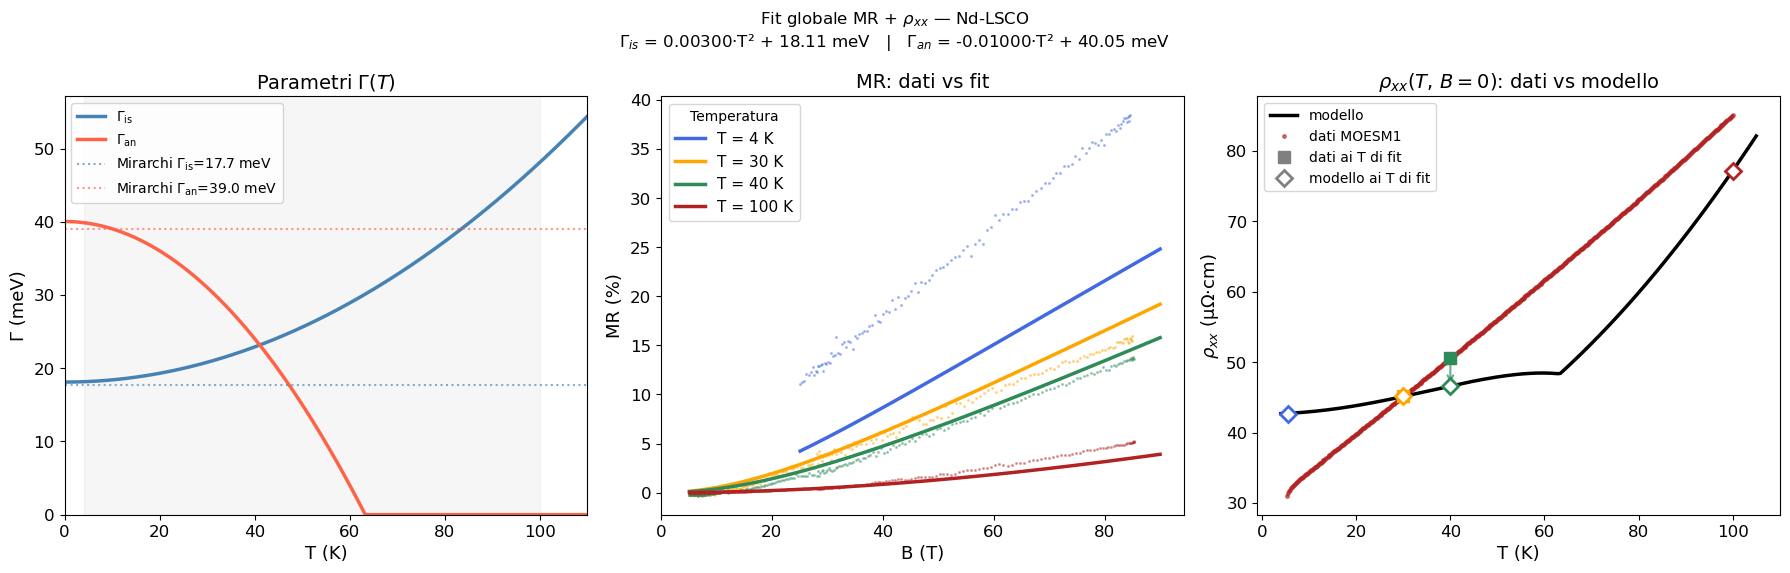

In [30]:
# ── Stile ────────────────────────────────────────────────────────────────
FS_AX = 13
FS_LG = 11
FS_TT = 14
FS_ST = 12

def _fmt_param_label(name, p, style):
    if style == 'linear':
        a, c = p
        if abs(a) < 1e-3:
            return fr'$\{name}$ = {c:.2f} meV'
        return fr'$\{name}$ = {a:.4f}·T + {c:.2f} meV'
    elif style == 'quadratic':
        a, c = p
        return fr'$\{name}$ = {a:.5f}·T² + {c:.2f} meV'
    return fr'$\{name}$ = {p[0]:.2f} meV'

T_fine_r0  = np.linspace(0, 110, 300)
gi_fine_r0 = [_eval_gamma(T, p_is_r0, T_DEP_IS_R0) for T in T_fine_r0]
ga_fine_r0 = [_eval_gamma(T, p_an_r0, T_DEP_AN_R0) for T in T_fine_r0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.8))
fig.suptitle(
    f'Fit globale MR + $\\rho_{{xx}}$ — {SAMPLE}\n'
    f'{_fmt_param_label("Gamma_{{is}}", p_is_r0, T_DEP_IS_R0)}'
    f'   |   '
    f'{_fmt_param_label("Gamma_{{an}}", p_an_r0, T_DEP_AN_R0)}',
    fontsize=FS_ST
)

# ── pannello 1: Γ(T) ──────────────────────────────────────────────────────
ax = axes[0]
ax.axvspan(min(T_LIST), max(T_LIST), alpha=0.07, color='gray', zorder=0)
ax.plot(T_fine_r0, gi_fine_r0, color='steelblue', lw=2.5,
        label=r'$\Gamma_{\rm is}$')
ax.plot(T_fine_r0, ga_fine_r0, color='tomato', lw=2.5,
        label=r'$\Gamma_{\rm an}$')
ax.axhline(MIR_G_IS, color='steelblue', ls=':', lw=1.5, alpha=0.65,
           label=f'Mirarchi $\\Gamma_{{\\rm is}}$={MIR_G_IS} meV')
ax.axhline(MIR_G_AN, color='tomato', ls=':', lw=1.5, alpha=0.65,
           label=f'Mirarchi $\\Gamma_{{\\rm an}}$={MIR_G_AN} meV')
ax.set_xlabel('T (K)', fontsize=FS_AX)
ax.set_ylabel('Γ (meV)', fontsize=FS_AX)
ax.set_title(r'Parametri $\Gamma(T)$', fontsize=FS_TT)
ax.set_xlim(0, 110); ax.set_ylim(bottom=0)
ax.tick_params(labelsize=FS_AX - 1)
ax.legend(fontsize=FS_LG - 1, loc='upper left')

# ── pannello 2: MR fit vs dati ────────────────────────────────────────────
ax2 = axes[1]
B_dense = np.linspace(1., 90., 300)
for T in T_LIST:
    B_data, MR_data = DATA[T]
    sel   = B_data > B_MIN[T]
    gi    = _eval_gamma(T, p_is_r0, T_DEP_IS_R0)
    ga    = _eval_gamma(T, p_an_r0, T_DEP_AN_R0)
    B_fit = B_dense[B_dense > B_MIN[T]]
    MR_fit = ENGINE.compute_MR(B_fit, gi, ga)
    ax2.plot(B_data[sel], MR_data[sel] * 100,
             '.', color=COLORS[T], ms=2.5, alpha=0.35, zorder=2)
    ax2.plot(B_fit, MR_fit * 100,
             '-', color=COLORS[T], lw=2.5, zorder=3, label=f'T = {T:.0f} K')
ax2.set_xlabel('B (T)', fontsize=FS_AX)
ax2.set_ylabel('MR (%)', fontsize=FS_AX)
ax2.set_title('MR: dati vs fit', fontsize=FS_TT)
ax2.set_xlim(left=0)
ax2.tick_params(labelsize=FS_AX - 1)
ax2.legend(fontsize=FS_LG, title='Temperatura', title_fontsize=FS_LG - 1)

# ── pannello 3: ρ_xx modello vs dati ─────────────────────────────────────
ax3 = axes[2]
T_arr_fine   = np.linspace(4, 105, 200)
rho_mod_fine = [ENGINE.compute_rho_xx(
    _eval_gamma(T, p_is_r0, T_DEP_IS_R0),
    _eval_gamma(T, p_an_r0, T_DEP_AN_R0)) for T in T_arr_fine]
ax3.plot(T_arr_fine, rho_mod_fine, 'k-', lw=2.5, label='modello', zorder=3)
ax3.plot(_T_nd, _rho_nd, '-', color='firebrick', lw=1.5, alpha=0.4, zorder=1)
ax3.plot(_T_nd, _rho_nd, 'o', color='firebrick', ms=2.5, alpha=0.6,
         zorder=2, label='dati MOESM1')

for T in T_LIST:
    gi    = _eval_gamma(T, p_is_r0, T_DEP_IS_R0)
    ga    = _eval_gamma(T, p_an_r0, T_DEP_AN_R0)
    rho_m = ENGINE.compute_rho_xx(gi, ga)
    rho_e = RHO_AT_T[T]
    T_plot = max(T, 5.5)
    ax3.plot(T_plot, rho_e, 's', color=COLORS[T], ms=9, zorder=5)
    ax3.plot(T_plot, rho_m, 'D', color=COLORS[T], ms=8, zorder=5,
             markerfacecolor='white', markeredgewidth=2)
    if np.isfinite(rho_e) and abs(rho_m - rho_e) > 3:
        ax3.annotate('', xy=(T_plot, rho_m), xytext=(T_plot, rho_e),
                     arrowprops=dict(arrowstyle='->', color=COLORS[T], lw=1.5, alpha=0.7))

_leg_extra = [
    Line2D([0],[0], marker='s', color='gray', ms=8, linestyle='None',
           label='dati ai T di fit'),
    Line2D([0],[0], marker='D', color='gray', ms=8, linestyle='None',
           markerfacecolor='white', markeredgewidth=2, label='modello ai T di fit'),
]
handles, labels = ax3.get_legend_handles_labels()
ax3.legend(handles + _leg_extra, labels + [h.get_label() for h in _leg_extra],
           fontsize=FS_LG - 1)
ax3.set_xlabel('T (K)', fontsize=FS_AX)
ax3.set_ylabel(r'$\rho_{xx}$ (µΩ·cm)', fontsize=FS_AX)
ax3.set_title(r'$\rho_{xx}(T,\,B{=}0)$: dati vs modello', fontsize=FS_TT)
ax3.tick_params(labelsize=FS_AX - 1)

plt.tight_layout()
plt.savefig('fit_numerico.png', dpi=150, bbox_inches='tight')
plt.show()


## Fit globale multi-T con vincolo su $R_H$ (Collignon 2017)

Aggiunge $R_H(T)$ come constraint fisico per rompere la degenerazione $\Gamma_{\rm is}$–$\Gamma_{\rm an}$.

**Implementazione**: $\sigma_{xy}$ calcolato con la stessa formula di Chambers, sostituendo $v_x \to v_y$ nel path-integral interno. Calibrazione unità: a $\Gamma_{\rm an}=0$ il modello deve dare $R_H = V_{\rm cell}/(e(1+p))$.

In [20]:
importlib.reload(ctb)
importlib.reload(cl)
ENGINE = ctb.ChambersFitEngine(N_fs=256)
K_MEV = ctb.K_MEV

find_mu... mu=-351.5 meV  (0.9s)
Fermi surface... N_fs=256  (0.01s)
percorsi backward... (0.00s)
cumsum A_is, A_an... (0.00s)
Engine pronto: N_fs=256, mu=-351.5 meV, perimetro FS=18.0578
Calibrazione R_H (weak-field): 0.9386 mm³/C, calib=1.8455e+05


R_H sperimentale ai 4 T di fit:
  T=    4 K:  R_H = 1.0053 mm³/C
  T=   30 K:  R_H = 1.0207 mm³/C
  T=   40 K:  R_H = 1.0119 mm³/C
  T=  100 K:  R_H = 0.9215 mm³/C

Check calibrazione a G_an=0 (weak-field): R_H = 0.9386 mm³/C  (atteso: 0.9386)


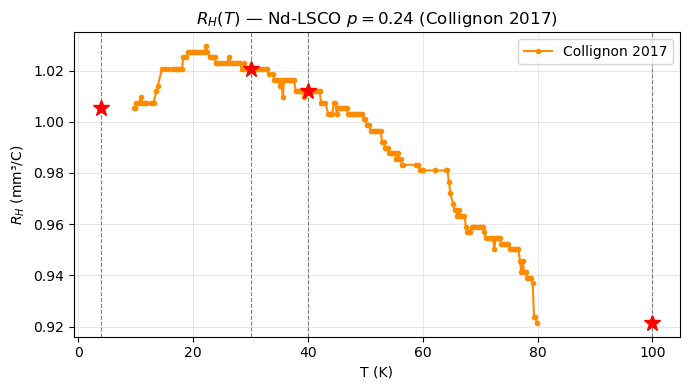

In [21]:
from scipy.interpolate import interp1d

rh_raw = np.loadtxt('Data/RH_NdLSCO_p024_Collignon2017.txt', comments='#')
T_rh_exp = rh_raw[:, 0]
RH_exp   = rh_raw[:, 1]

_rh_interp = interp1d(T_rh_exp, RH_exp, kind='linear',
                      bounds_error=False,
                      fill_value=(RH_exp[0], RH_exp[-1]))
RH_AT_T = {T: float(_rh_interp(T)) for T in T_LIST}

print('R_H sperimentale ai 4 T di fit:')
for T, v in RH_AT_T.items():
    print(f'  T={T:5.0f} K:  R_H = {v:.4f} mm³/C')

# Verifica calibrazione: a G_an=0 deve tornare ~RH_iso_phys
rh_check = ENGINE.compute_RH(10.0, 0.0)
print(f'\nCheck calibrazione a G_an=0 (weak-field): '
      f'R_H = {rh_check:.4f} mm³/C  (atteso: {ENGINE.RH_iso_phys:.4f})')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(T_rh_exp, RH_exp, 'o-', ms=3, color='darkorange', label='Collignon 2017')
for T, v in RH_AT_T.items():
    ax.axvline(T, color='gray', lw=0.8, ls='--')
    ax.plot(T, v, 'r*', ms=12, zorder=5)
ax.set_xlabel('T (K)'); ax.set_ylabel(r'$R_H$ (mm³/C)')
ax.set_title(r'$R_H(T)$ — Nd-LSCO $p=0.24$ (Collignon 2017)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [22]:
# T=100K escluso: R_H_exp(100K)~0.92 < R_H_iso=0.94 (non raggiungibile col modello per G_an>=0)
T_RH_LIST    = [4.0, 30.0, 40.0]
T_DEP_IS_RH  = 'quadratic'
T_DEP_AN_RH  = 'linear'
PESO_CW_RH   = 10.0
W_RH_GLOBAL  = 200.0   # peso relativo del vincolo R_H vs MR

_BND_RH = {
    'constant':  dict(lb=[1.],       ub=[39.2]),
    'linear':    dict(lb=[0.,  0.],  ub=[1.,  30.]),
    'quadratic': dict(lb=[0.,  0.],  ub=[0.05, 40.]),
}

n_is_rh = _npar(T_DEP_IS_RH)
n_an_rh = _npar(T_DEP_AN_RH)

_per_T_rh = {}
for _T, (_B, _MR) in DATA.items():
    _ok = np.isfinite(_B) & np.isfinite(_MR) & (_B > B_MIN[_T])
    _Bf, _MRf = _B[_ok], _MR[_ok]
    _W = np.ones_like(_Bf)
    _W[(_Bf >= 10.) & (_Bf <= 30.)] = PESO_CW_RH
    _per_T_rh[_T] = (_Bf, _MRf, _W)

def residual_glob_rh(p):
    p_is = p[:n_is_rh]
    p_an = p[n_is_rh:]
    parts = []
    # Residui MR (tutte le 4 temperature)
    for T, (Bf, MRf, W) in _per_T_rh.items():
        gi = _eval_gamma(T, p_is, T_DEP_IS_RH)
        ga = _eval_gamma(T, p_an, T_DEP_AN_RH)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            MR_th = np.nan_to_num(ENGINE.compute_MR(Bf, gi, ga), nan=0.)
        parts.append((MR_th - MRf) * W)
    # Residui R_H (weak-field) — solo T dove R_H_exp > R_H_iso (escluso 100K)
    for T in T_RH_LIST:
        gi = _eval_gamma(T, p_is, T_DEP_IS_RH)
        ga = _eval_gamma(T, p_an, T_DEP_AN_RH)
        RH_th    = ENGINE.compute_RH(gi, ga)
        RH_exp_T = RH_AT_T[T]
        parts.append(np.array([W_RH_GLOBAL * (RH_th - RH_exp_T)]))
    return np.concatenate(parts)

print(f'Residuo combinato: {n_is_rh+n_an_rh} parametri, '
      f'MR={sum(len(v[0]) for v in _per_T_rh.values())} punti + '
      f'RH={len(T_RH_LIST)} punti (peso {W_RH_GLOBAL}x)')


Residuo combinato: 4 parametri, MR=757 punti + RH=3 punti (peso 200.0x)


In [23]:
N_STARTS_RH = 8

lb_rh = np.array(_BND_RH[T_DEP_IS_RH]['lb'] + _BND_RH[T_DEP_AN_RH]['lb'])
ub_rh = np.array(_BND_RH[T_DEP_IS_RH]['ub'] + _BND_RH[T_DEP_AN_RH]['ub'])

p0_rh = np.clip(
    np.array(_p0_from_mirarchi(T_DEP_IS_RH, MIR_G_IS) +
             _p0_from_mirarchi(T_DEP_AN_RH, MIR_G_AN)),
    lb_rh + 1e-8, ub_rh - 1e-8
)

rng_rh = np.random.default_rng(7)
starts_rh = [p0_rh] + [rng_rh.uniform(lb_rh, ub_rh) for _ in range(N_STARTS_RH-1)]

best_rh, best_cost_rh = None, np.inf
print(f'Fit MR+RH: Γ_is~{T_DEP_IS_RH}, Γ_an~{T_DEP_AN_RH} ({n_is_rh+n_an_rh} param)\n')

for k, p0 in enumerate(tqdm(starts_rh, desc='multi-start MR+RH', unit='start')):
    try:
        res = least_squares(
            residual_glob_rh, p0,
            bounds=(lb_rh, ub_rh),
            loss='soft_l1', f_scale=0.01,
            ftol=1e-10, xtol=1e-10, gtol=1e-8,
            max_nfev=5000,
            x_scale=(ub_rh - lb_rh),
        )
        cost = res.cost
        tqdm.write(f'  start {k+1}/{len(starts_rh)}: cost={cost:.6f}  p={np.round(res.x, 4)}')
        if cost < best_cost_rh:
            best_cost_rh, best_rh = cost, res
    except Exception as e:
        tqdm.write(f'  start {k+1} fallito: {e}')

p_rh = best_rh.x
p_is_rh = p_rh[:n_is_rh]
p_an_rh = p_rh[n_is_rh:]

print(f'\n── Risultato MR+RH ──────────────────────────────────────')
print(f'  {_label_gamma("Gamma_{{is}}", p_is_rh, T_DEP_IS_RH)}')
print(f'  {_label_gamma("Gamma_{{an}}", p_an_rh, T_DEP_AN_RH)}')
print(f'  RMS globale: {np.sqrt(2*best_cost_rh/len(best_rh.fun)):.5f}')
print(f'\n{"T (K)":>8}  {"Γ_is (meV)":>12}  {"Γ_an (meV)":>12}  {"R_H mod":>10}  {"R_H exp":>10}')
for T in T_LIST:
    gi = _eval_gamma(T, p_is_rh, T_DEP_IS_RH)
    ga = _eval_gamma(T, p_an_rh, T_DEP_AN_RH)
    rh_m = ENGINE.compute_RH(gi, ga)
    rh_e = RH_AT_T[T]
    print(f'{T:8.0f}  {gi:12.2f}  {ga:12.2f}  {rh_m:10.4f}  {rh_e:10.4f}')

Fit MR+RH: Γ_is~quadratic, Γ_an~linear (4 param)



multi-start MR+RH:   0%|          | 0/8 [00:00<?, ?start/s]

  start 1/8: cost=0.135170  p=[0.0099 8.8937 0.1728 2.3863]
  start 2/8: cost=0.135170  p=[0.0099 8.8937 0.1728 2.3863]
  start 3/8: cost=0.135170  p=[0.0099 8.8937 0.1728 2.3863]
  start 4/8: cost=0.135170  p=[0.0099 8.8937 0.1728 2.3863]
  start 5/8: cost=0.135170  p=[0.0099 8.8937 0.1728 2.3863]
  start 6/8: cost=0.135170  p=[0.0099 8.8937 0.1728 2.3863]
  start 7/8: cost=0.135170  p=[0.0099 8.8937 0.1728 2.3863]
  start 8/8: cost=0.135170  p=[0.0099 8.8937 0.1728 2.3863]

── Risultato MR+RH ──────────────────────────────────────
  $Gamma_{{is}}$ = 0.00992·T² + 8.89 meV
  $Gamma_{{an}}$ = 0.1728·T + 2.39 meV
  RMS globale: 0.01886

   T (K)    Γ_is (meV)    Γ_an (meV)     R_H mod     R_H exp
       4          9.05          3.08      1.0053      1.0053
      30         17.82          7.57      1.0208      1.0207
      40         24.76          9.30      1.0118      1.0119
     100        108.08         19.67      0.9753      0.9215


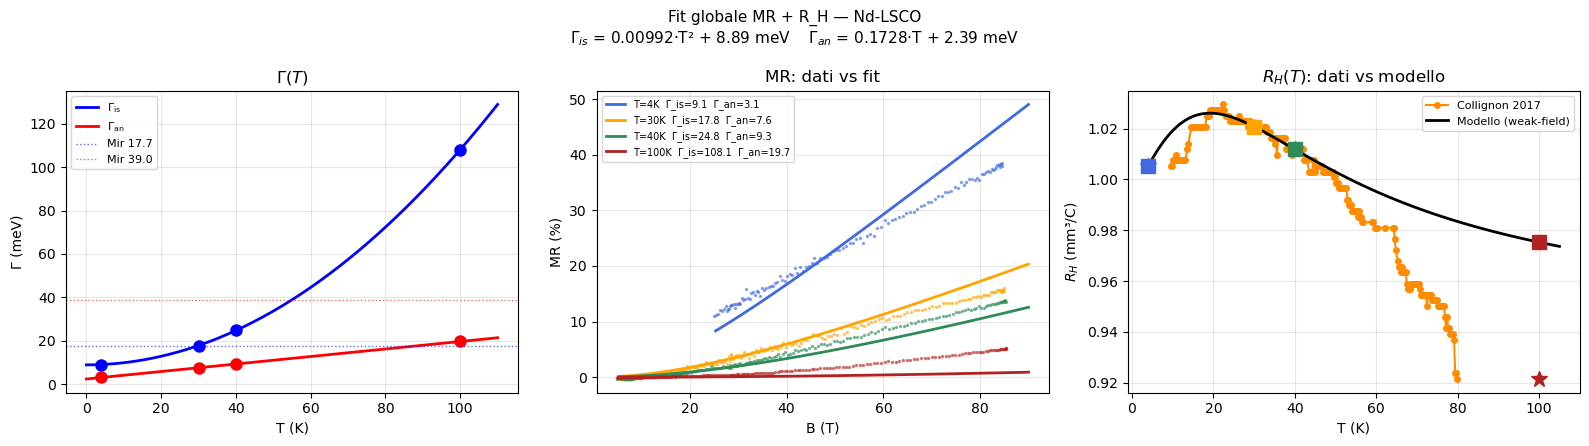

In [28]:
T_fine_rh = np.linspace(0, 110, 300)
gi_fine_rh = [_eval_gamma(T, p_is_rh, T_DEP_IS_RH) for T in T_fine_rh]
ga_fine_rh = [_eval_gamma(T, p_an_rh, T_DEP_AN_RH) for T in T_fine_rh]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle(f'Fit globale MR + R_H — Nd-LSCO\n'
             f'{_label_gamma("Γ_{{is}}", p_is_rh, T_DEP_IS_RH)}    '
             f'{_label_gamma("Γ_{{an}}", p_an_rh, T_DEP_AN_RH)}', 
             fontsize=11)

ax = axes[0]
ax.plot(T_fine_rh, gi_fine_rh, 'b-', lw=2, label=r'$\Gamma_{\rm is}$')
ax.plot(T_fine_rh, ga_fine_rh, 'r-', lw=2, label=r'$\Gamma_{\rm an}$')
ax.plot(T_LIST, [_eval_gamma(T, p_is_rh, T_DEP_IS_RH) for T in T_LIST], 'bo', ms=8)
ax.plot(T_LIST, [_eval_gamma(T, p_an_rh, T_DEP_AN_RH) for T in T_LIST], 'ro', ms=8)
ax.axhline(MIR_G_IS, color='blue', ls=':', lw=1, alpha=0.6, label=f'Mir {MIR_G_IS}')
ax.axhline(MIR_G_AN, color='red',  ls=':', lw=1, alpha=0.6, label=f'Mir {MIR_G_AN}')
ax.set_xlabel('T (K)'); ax.set_ylabel('Γ (meV)')
ax.set_title(r'$\Gamma(T)$'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax2 = axes[1]
B_dense = np.linspace(1., 90., 250)
for T in T_LIST:
    B_data, MR_data = DATA[T]
    gi = _eval_gamma(T, p_is_rh, T_DEP_IS_RH)
    ga = _eval_gamma(T, p_an_rh, T_DEP_AN_RH)
    B_fit = B_dense[B_dense > B_MIN[T]]
    MR_fit = ENGINE.compute_MR(B_fit, gi, ga)
    ax2.plot(B_data, MR_data * 100, '.', color=COLORS[T], ms=3, alpha=0.5)
    ax2.plot(B_fit, MR_fit * 100, '-', color=COLORS[T], lw=2,
             label=f'T={T:.0f}K  Γ_is={gi:.1f}  Γ_an={ga:.1f}')
ax2.set_xlabel('B (T)'); ax2.set_ylabel('MR (%)'); ax2.set_title('MR: dati vs fit')
ax2.legend(fontsize=7); ax2.grid(True, alpha=0.3)

ax3 = axes[2]
ax3.plot(T_rh_exp, RH_exp, 'o-', ms=4, color='darkorange', lw=1.5, label='Collignon 2017')
T_fine_rh2 = np.linspace(5, 105, 200)
RH_model_fine = [ENGINE.compute_RH(_eval_gamma(T, p_is_rh, T_DEP_IS_RH),
                                    _eval_gamma(T, p_an_rh, T_DEP_AN_RH))
                  for T in T_fine_rh2]
ax3.plot(T_fine_rh2, RH_model_fine, 'k-', lw=2, label='Modello (weak-field)')
for T in T_LIST:
    gi = _eval_gamma(T, p_is_rh, T_DEP_IS_RH)
    ga = _eval_gamma(T, p_an_rh, T_DEP_AN_RH)
    rh_m = ENGINE.compute_RH(gi, ga)
    ax3.plot(T, rh_m,       's', color=COLORS[T], ms=10, zorder=5, label='_')
    ax3.plot(T, RH_AT_T[T], '*', color=COLORS[T], ms=12, zorder=5, label='_')
ax3.set_xlabel('T (K)'); ax3.set_ylabel(r'$R_H$ (mm³/C)')
ax3.set_title(r'$R_H(T)$: dati vs modello')
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()